BIVARIATE EXPLORATORY DATA ANALYSIS

Dataset: 70,000 rows × 26 columns

CORRELATION ANALYSIS - NUMERICAL FEATURES


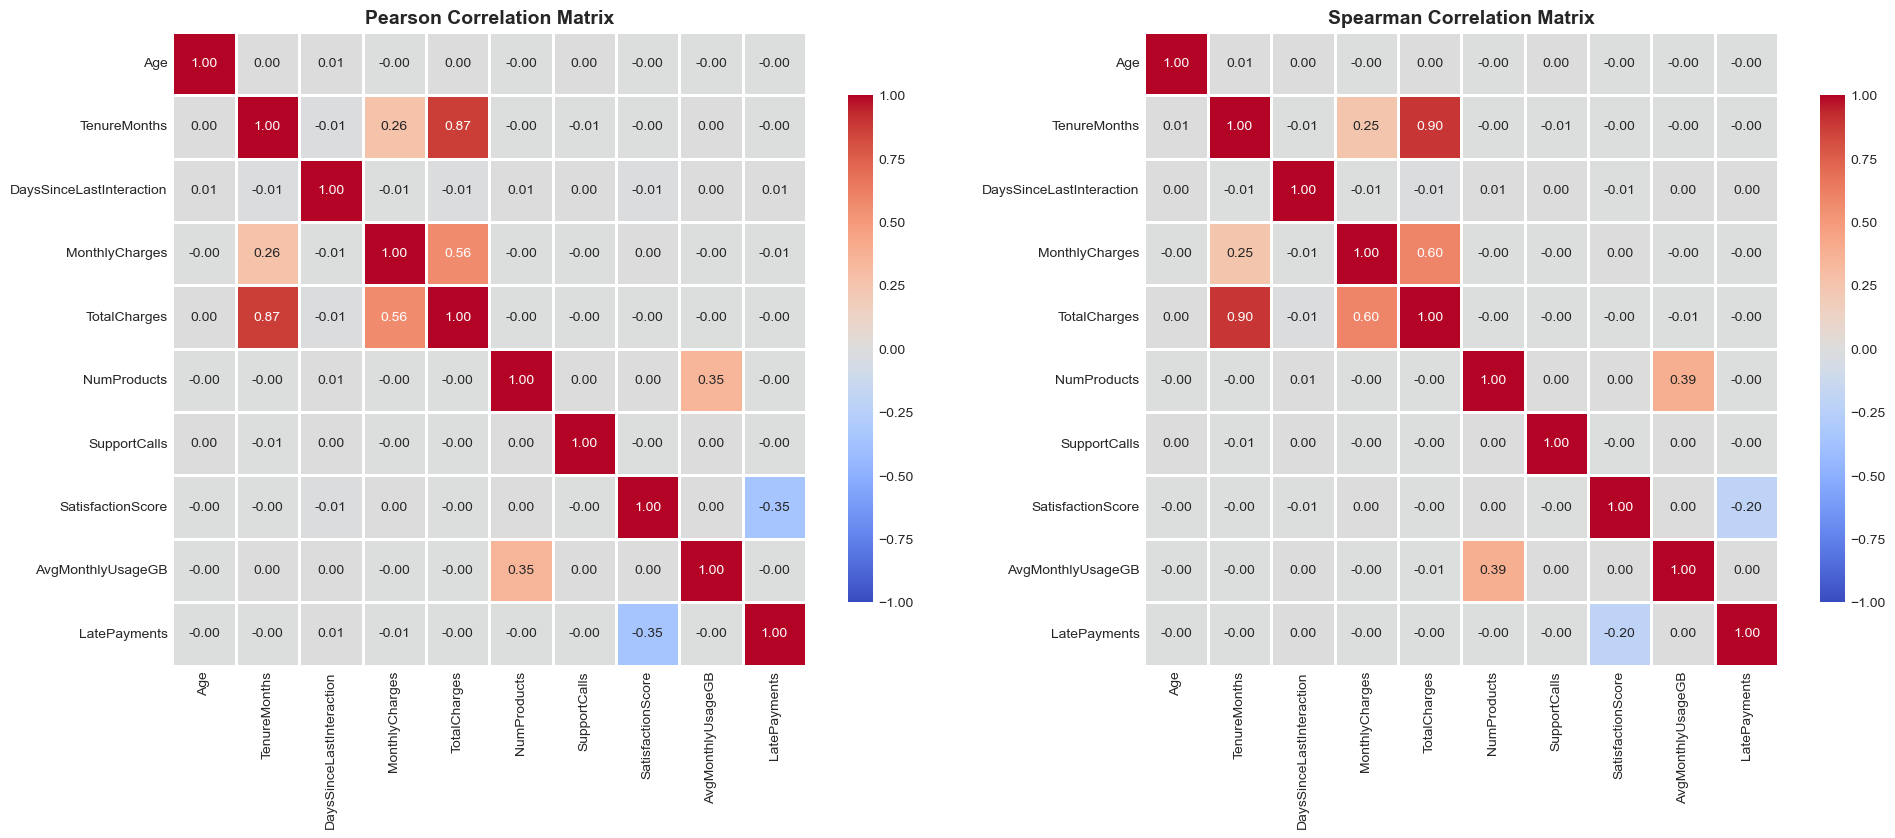


Strong Correlations (|r| > 0.5):
     Feature 1    Feature 2  Correlation
  TenureMonths TotalCharges     0.870797
MonthlyCharges TotalCharges     0.564417

PAIRWISE RELATIONSHIPS - KEY FEATURES


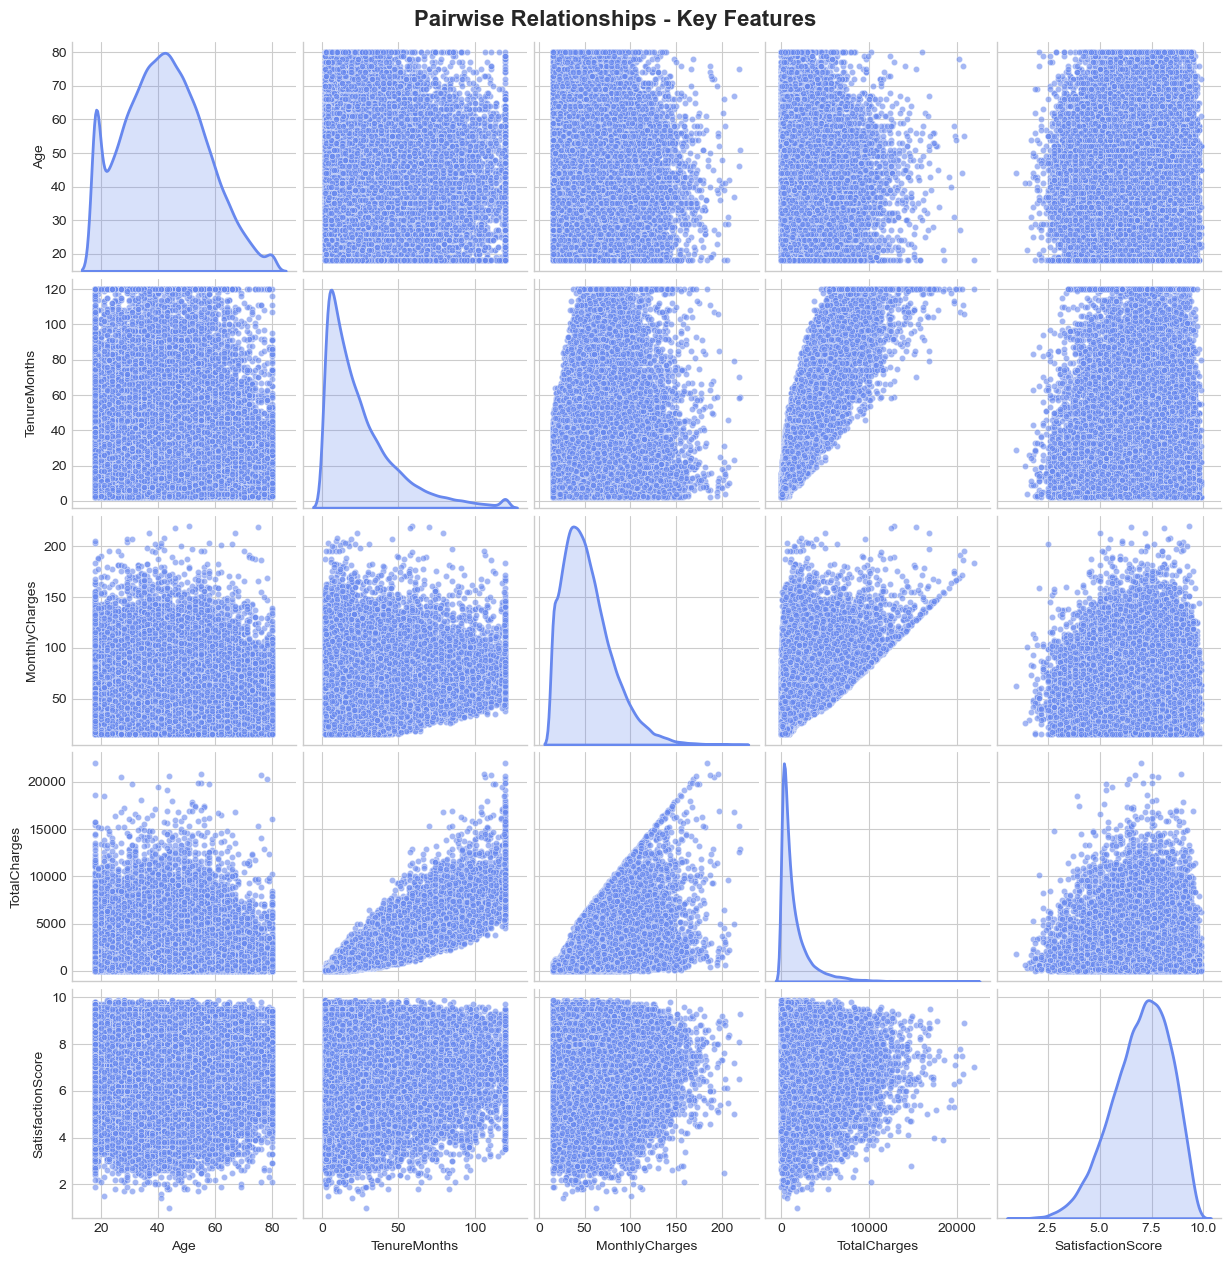


DETAILED SCATTER PLOTS WITH REGRESSION


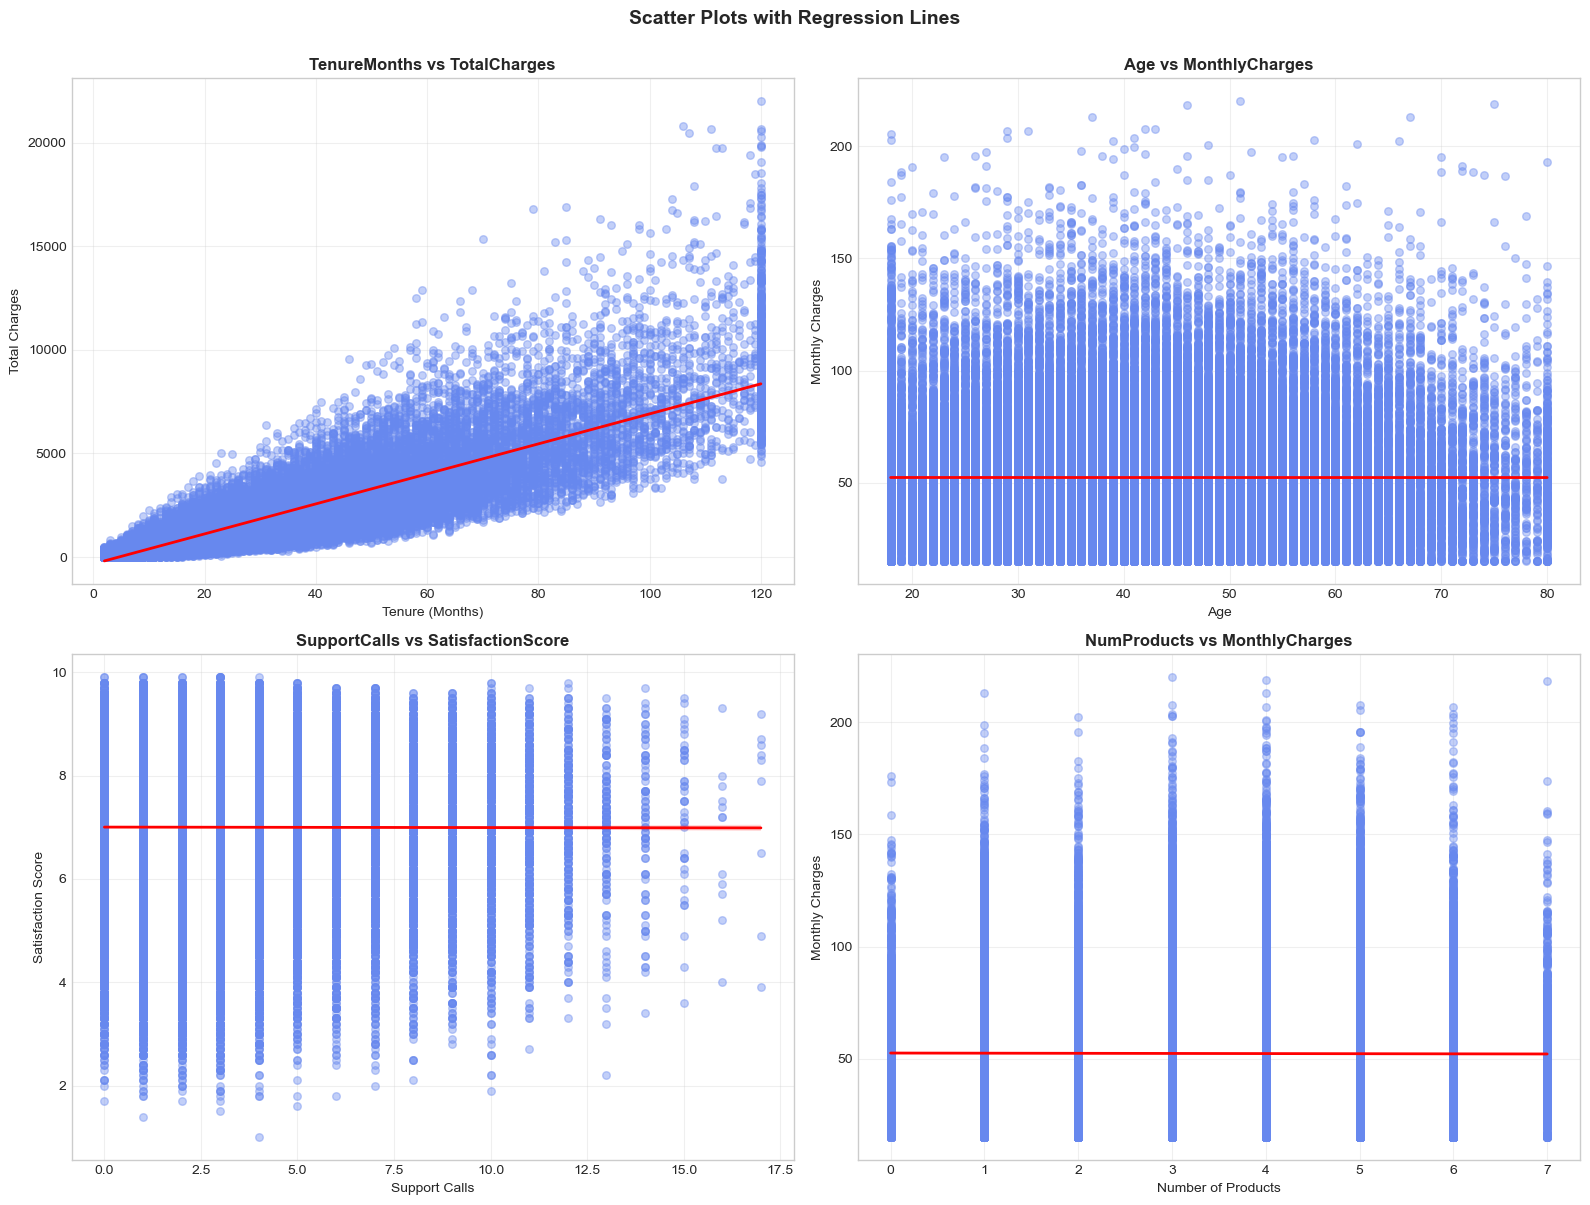


CATEGORICAL vs NUMERICAL RELATIONSHIPS


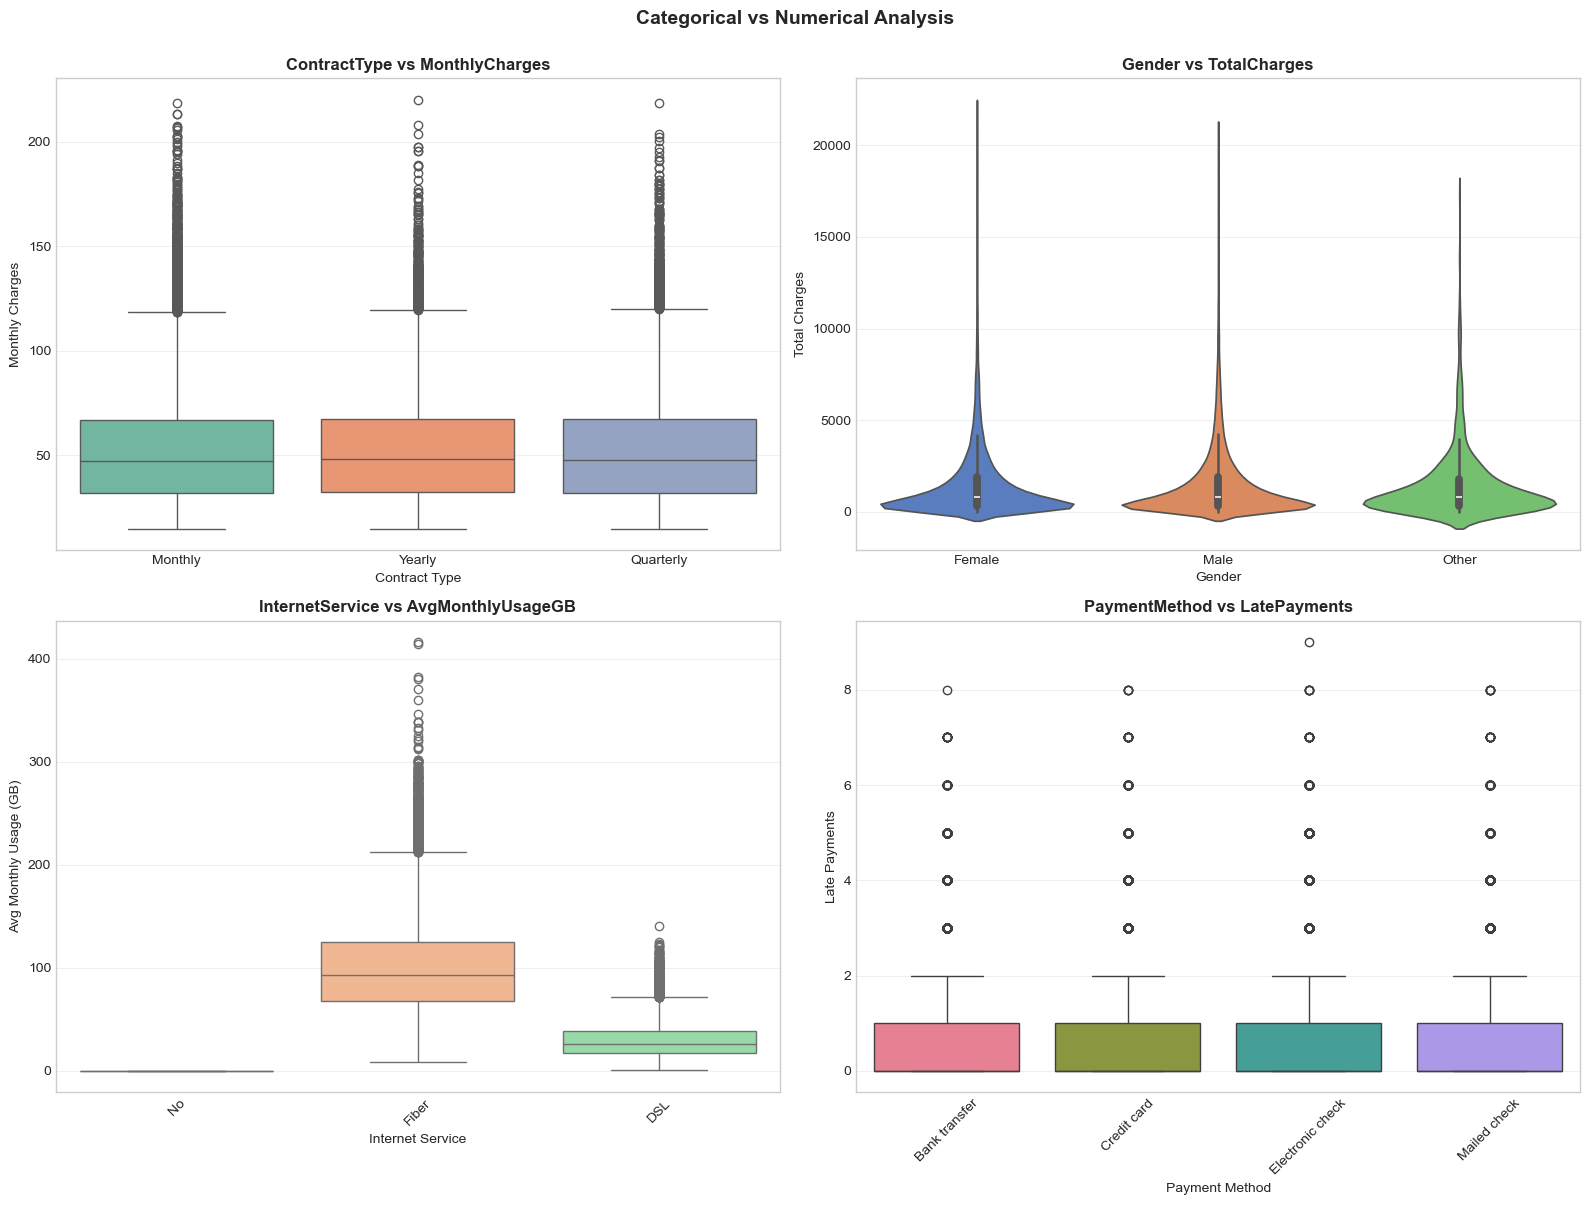


CATEGORICAL vs CATEGORICAL RELATIONSHIPS


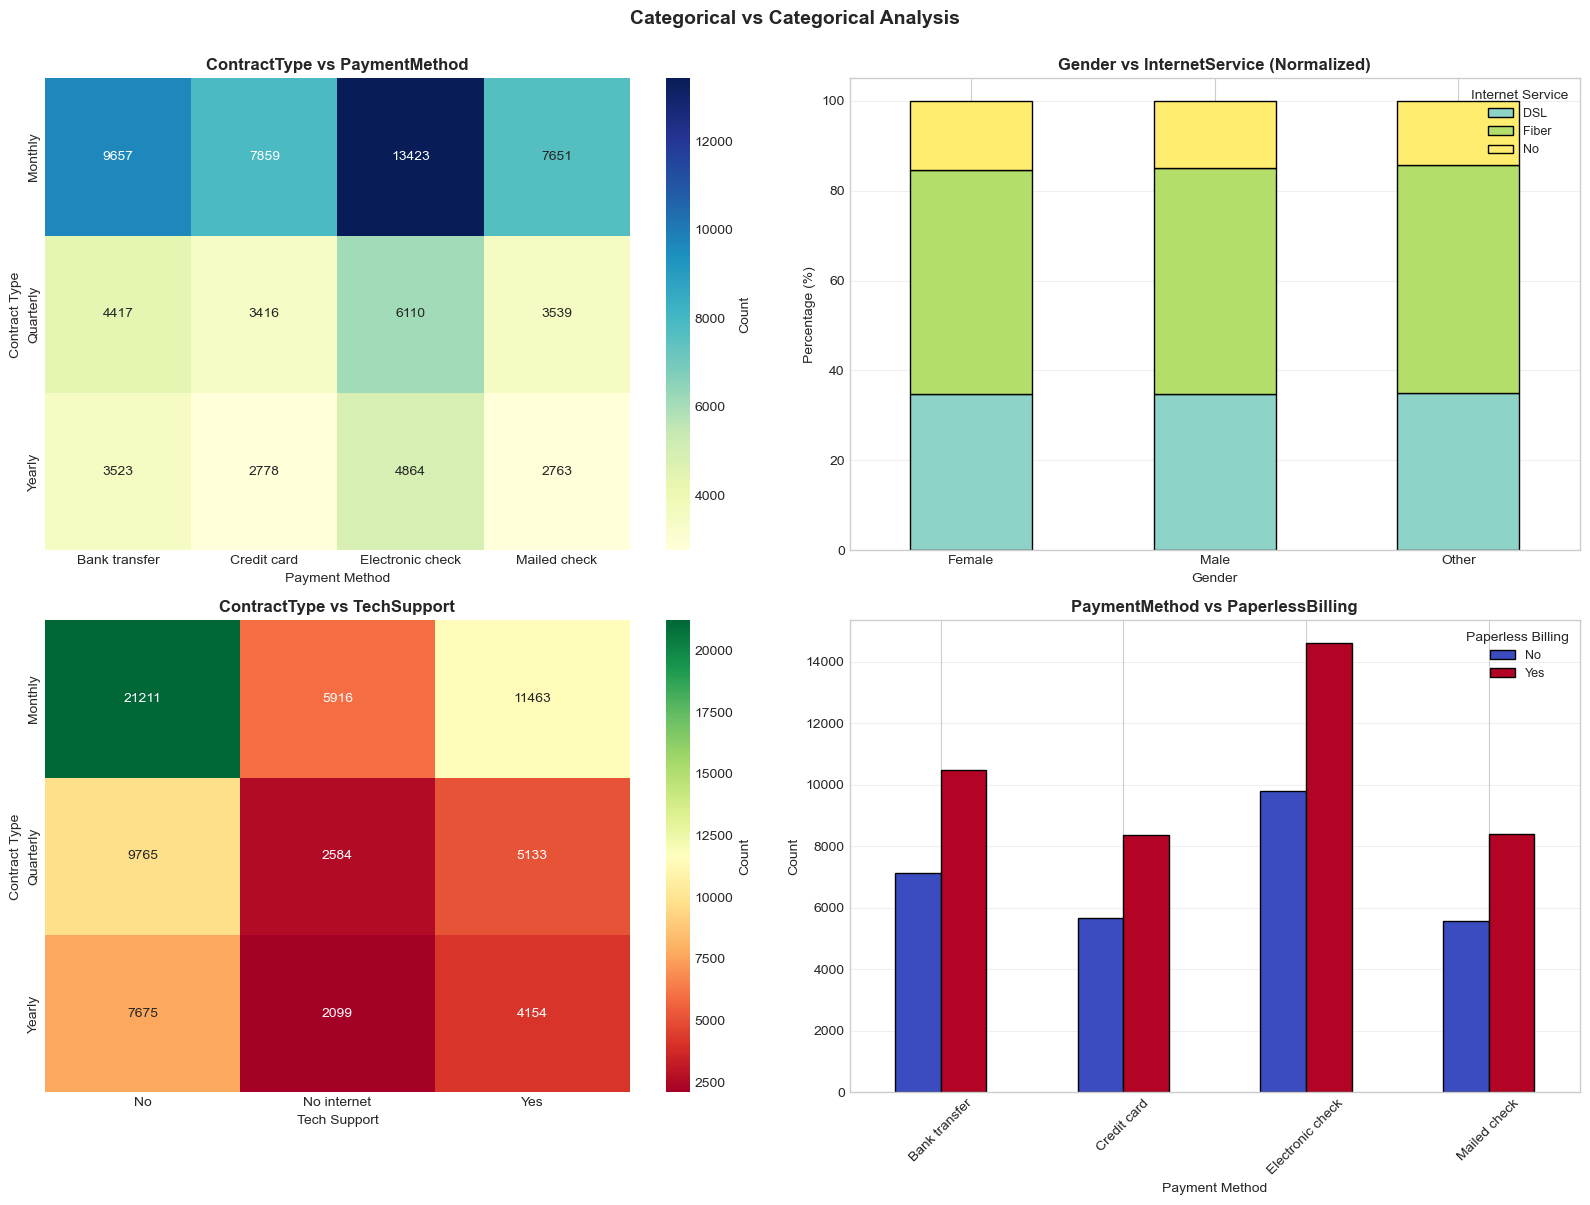


CHI-SQUARE TEST - CATEGORICAL ASSOCIATIONS
    Feature 1        Feature 2  Chi-Square  P-Value  DOF Significant
 ContractType    PaymentMethod    5.925567 0.431580    6          No
       Gender  InternetService    2.261707 0.687749    4          No
 ContractType      TechSupport    4.902906 0.297406    4          No
PaymentMethod PaperlessBilling    1.442646 0.695569    3          No

CORRELATION WITH P-VALUES

Top 10 Correlations with P-Values:
               Feature 1                Feature 2  Correlation  P-Value Significant
            TenureMonths             TotalCharges     0.870797 0.000000         Yes
          MonthlyCharges             TotalCharges     0.564417 0.000000         Yes
       SatisfactionScore             LatePayments    -0.352742 0.000000         Yes
             NumProducts        AvgMonthlyUsageGB     0.348857 0.000000         Yes
            TenureMonths           MonthlyCharges     0.260475 0.000000         Yes
            TenureMonths DaysSinceLastIntera

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 04: BIVARIATE EXPLORATORY DATA ANALYSIS
# Purpose: Analyze relationships between features
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("coolwarm")
pd.set_option('display.max_columns', None)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('../data/raw/customer_churn_dataset.csv')

print("="*80)
print("BIVARIATE EXPLORATORY DATA ANALYSIS")
print("="*80)
print(f"\nDataset: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

numerical_cols = ['Age', 'TenureMonths', 'DaysSinceLastInteraction', 'MonthlyCharges', 
                  'TotalCharges', 'NumProducts', 'SupportCalls', 'SatisfactionScore', 
                  'AvgMonthlyUsageGB', 'LatePayments']

categorical_cols = ['Gender', 'City', 'ContractType', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'PaymentMethod', 'PaperlessBilling']

# ═══════════════════════════════════════════════════════════════════════════════
# 2. CORRELATION ANALYSIS (NUMERICAL vs NUMERICAL)
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("CORRELATION ANALYSIS - NUMERICAL FEATURES")
print("="*80)

# Pearson correlation
corr_matrix = df[numerical_cols].corr()

# Visualization heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson Correlation
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0],
            vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')

# Spearman Correlation
spearman_corr = df[numerical_cols].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[1],
            vmin=-1, vmax=1)
axes[1].set_title('Spearman Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/results/04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Identification of strong correlations
print("\nStrong Correlations (|r| > 0.5):")
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            strong_corr.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
    print(strong_corr_df.to_string(index=False))
else:
    print("No strong correlations found.")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. PAIRWISE SCATTER PLOTS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("PAIRWISE RELATIONSHIPS - KEY FEATURES")
print("="*80)

# key features for scatter plot
key_features = ['Age', 'TenureMonths', 'MonthlyCharges', 'TotalCharges', 'SatisfactionScore']

# Pairplot
pairplot_fig = sns.pairplot(df[key_features].dropna(), diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20},
                             diag_kws={'linewidth': 2})
pairplot_fig.fig.suptitle('Pairwise Relationships - Key Features', y=1.01, fontsize=16, fontweight='bold')
plt.savefig('../data/results/04_pairplot_key_features.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. SCATTER PLOTS WITH REGRESSION LINES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("DETAILED SCATTER PLOTS WITH REGRESSION")
print("="*80)

# TenureMonths and TotalCharges
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# TenureMonths vs TotalCharges
sns.regplot(x='TenureMonths', y='TotalCharges', data=df, ax=axes[0, 0], 
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': 'red', 'linewidth': 2})
axes[0, 0].set_title('TenureMonths vs TotalCharges', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tenure (Months)', fontsize=10)
axes[0, 0].set_ylabel('Total Charges', fontsize=10)
axes[0, 0].grid(alpha=0.3)

# Age vs MonthlyCharges
sns.regplot(x='Age', y='MonthlyCharges', data=df, ax=axes[0, 1],
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': 'red', 'linewidth': 2})
axes[0, 1].set_title('Age vs MonthlyCharges', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age', fontsize=10)
axes[0, 1].set_ylabel('Monthly Charges', fontsize=10)
axes[0, 1].grid(alpha=0.3)

# SupportCalls vs SatisfactionScore
sns.regplot(x='SupportCalls', y='SatisfactionScore', data=df, ax=axes[1, 0],
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': 'red', 'linewidth': 2})
axes[1, 0].set_title('SupportCalls vs SatisfactionScore', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Support Calls', fontsize=10)
axes[1, 0].set_ylabel('Satisfaction Score', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# NumProducts vs MonthlyCharges
sns.regplot(x='NumProducts', y='MonthlyCharges', data=df, ax=axes[1, 1],
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': 'red', 'linewidth': 2})
axes[1, 1].set_title('NumProducts vs MonthlyCharges', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Products', fontsize=10)
axes[1, 1].set_ylabel('Monthly Charges', fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Scatter Plots with Regression Lines', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/04_scatter_regression.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. CATEGORICAL vs NUMERICAL ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CATEGORICAL vs NUMERICAL RELATIONSHIPS")
print("="*80)

# ContractType vs MonthlyCharges
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ContractType vs MonthlyCharges
sns.boxplot(x='ContractType', y='MonthlyCharges', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('ContractType vs MonthlyCharges', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Contract Type', fontsize=10)
axes[0, 0].set_ylabel('Monthly Charges', fontsize=10)
axes[0, 0].grid(axis='y', alpha=0.3)

# Gender vs TotalCharges
sns.violinplot(x='Gender', y='TotalCharges', data=df, ax=axes[0, 1], palette='muted')
axes[0, 1].set_title('Gender vs TotalCharges', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Gender', fontsize=10)
axes[0, 1].set_ylabel('Total Charges', fontsize=10)
axes[0, 1].grid(axis='y', alpha=0.3)

# InternetService vs AvgMonthlyUsageGB
sns.boxplot(x='InternetService', y='AvgMonthlyUsageGB', data=df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('InternetService vs AvgMonthlyUsageGB', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Internet Service', fontsize=10)
axes[1, 0].set_ylabel('Avg Monthly Usage (GB)', fontsize=10)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# PaymentMethod vs LatePayments
sns.boxplot(x='PaymentMethod', y='LatePayments', data=df, ax=axes[1, 1], palette='husl')
axes[1, 1].set_title('PaymentMethod vs LatePayments', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Payment Method', fontsize=10)
axes[1, 1].set_ylabel('Late Payments', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Categorical vs Numerical Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/04_categorical_numerical.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. CATEGORICAL vs CATEGORICAL ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CATEGORICAL vs CATEGORICAL RELATIONSHIPS")
print("="*80)

# ContractType vs PaymentMethod
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ContractType vs PaymentMethod - Heatmap
ct_pm = pd.crosstab(df['ContractType'], df['PaymentMethod'])
sns.heatmap(ct_pm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0, 0], cbar_kws={'label': 'Count'})
axes[0, 0].set_title('ContractType vs PaymentMethod', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Payment Method', fontsize=10)
axes[0, 0].set_ylabel('Contract Type', fontsize=10)

# Gender vs InternetService - Stacked Bar
gender_internet = pd.crosstab(df['Gender'], df['InternetService'], normalize='index') * 100
gender_internet.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Set3', edgecolor='black')
axes[0, 1].set_title('Gender vs InternetService (Normalized)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Gender', fontsize=10)
axes[0, 1].set_ylabel('Percentage (%)', fontsize=10)
axes[0, 1].legend(title='Internet Service', fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].grid(axis='y', alpha=0.3)

# ContractType vs TechSupport - Heatmap
ct_ts = pd.crosstab(df['ContractType'], df['TechSupport'])
sns.heatmap(ct_ts, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_title('ContractType vs TechSupport', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tech Support', fontsize=10)
axes[1, 0].set_ylabel('Contract Type', fontsize=10)

# PaymentMethod vs PaperlessBilling - Grouped Bar
pm_pb = pd.crosstab(df['PaymentMethod'], df['PaperlessBilling'])
pm_pb.plot(kind='bar', ax=axes[1, 1], colormap='coolwarm', edgecolor='black')
axes[1, 1].set_title('PaymentMethod vs PaperlessBilling', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Payment Method', fontsize=10)
axes[1, 1].set_ylabel('Count', fontsize=10)
axes[1, 1].legend(title='Paperless Billing', fontsize=9)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Categorical vs Categorical Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../data/results/04_categorical_categorical.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 7. CHI-SQUARE TEST FOR CATEGORICAL ASSOCIATIONS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CHI-SQUARE TEST - CATEGORICAL ASSOCIATIONS")
print("="*80)

cat_pairs = [
    ('ContractType', 'PaymentMethod'),
    ('Gender', 'InternetService'),
    ('ContractType', 'TechSupport'),
    ('PaymentMethod', 'PaperlessBilling')
]

chi_results = []
for cat1, cat2 in cat_pairs:
    contingency_table = pd.crosstab(df[cat1], df[cat2])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    chi_results.append({
        'Feature 1': cat1,
        'Feature 2': cat2,
        'Chi-Square': chi2,
        'P-Value': p_value,
        'DOF': dof,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results)
print(chi_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# 8. CORRELATION WITH STATISTICAL SIGNIFICANCE
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CORRELATION WITH P-VALUES")
print("="*80)

corr_pvalues = []
for i, col1 in enumerate(numerical_cols):
    for j, col2 in enumerate(numerical_cols):
        if i < j:
            # حذف missing values
            valid_data = df[[col1, col2]].dropna()
            if len(valid_data) > 0:
                corr, p_val = pearsonr(valid_data[col1], valid_data[col2])
                corr_pvalues.append({
                    'Feature 1': col1,
                    'Feature 2': col2,
                    'Correlation': corr,
                    'P-Value': p_val,
                    'Significant': 'Yes' if p_val < 0.05 else 'No'
                })

corr_pval_df = pd.DataFrame(corr_pvalues).sort_values('Correlation', key=abs, ascending=False)
print("\nTop 10 Correlations with P-Values:")
print(corr_pval_df.head(10).to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# 9. SUMMARY STATISTICS BY GROUPS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SUMMARY STATISTICS BY CATEGORICAL GROUPS")
print("="*80)

# MonthlyCharges by ContractType
print("\nMonthlyCharges by ContractType:")
print(df.groupby('ContractType')['MonthlyCharges'].describe().round(2))

# TotalCharges by Gender
print("\nTotalCharges by Gender:")
print(df.groupby('Gender')['TotalCharges'].describe().round(2))

# SatisfactionScore by InternetService
print("\nSatisfactionScore by InternetService:")
print(df.groupby('InternetService')['SatisfactionScore'].describe().round(2))

print("\n" + "="*80)
print("BIVARIATE EDA COMPLETED")
print("="*80)
